In [1]:
%%capture
## [TEMPLATE BEGIN]
## おまじない：実行中のノートブック名からOUTPUT_DIRを決めるコード
from pathlib import Path
from IPython import get_ipython; ip = get_ipython()
if '__vsc_ipynb_file__' in ip.user_ns:
    ## VS Codeで実行されている場合
    THIS_NOTEBOOK_PATH = Path(ip.user_ns['__vsc_ipynb_file__'])
else:
    !pip install ipynbname
    import ipynbname; THIS_NOTEBOOK_PATH = Path(ipynbname.path())
    if "%2F" in THIS_NOTEBOOK_PATH.stem:
        ## Google Colabで実行されている場合
        colab_ip = %system hostname -I   # uses colab magic to get list from bash
        colab_ip = colab_ip[0].strip()   # returns "172.28.0.12"
        colab_port = 9000                # could use 6000, 8080, or 9000
        import requests
        filename = requests.get(f"http://{colab_ip}:{colab_port}/api/sessions").json()[0]["name"]
        THIS_NOTEBOOK_PATH = Path(filename)
    else:
        ## それ以外の場合
        THIS_NOTEBOOK_PATH = THIS_NOTEBOOK_PATH

OUTPUT_DIR = Path("figures") / THIS_NOTEBOOK_PATH.stem
## [TEMPLATE END]

In [2]:
print("File output directory:", OUTPUT_DIR)
# Create the output directory if it does not exist
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

File output directory: figures/_logistic_functions


Plot 1: Simple linear combination: 1 + x1 + x2


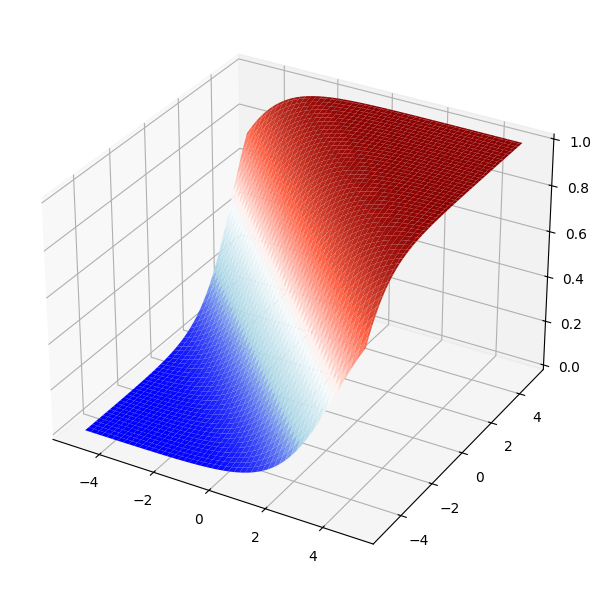

Plot 2: Quadratic terms: 1 + 0.1*x1^2 + 0.1*x2^2


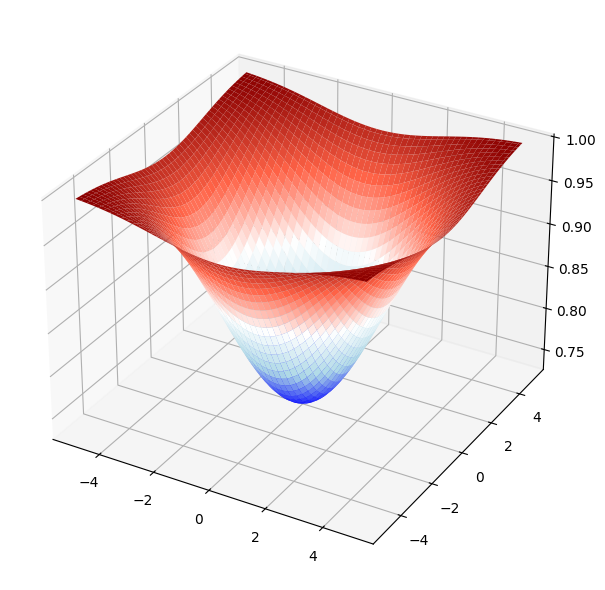

Plot 3: Linear with interaction: 1 + x1 + 2*x2 + x1*x2


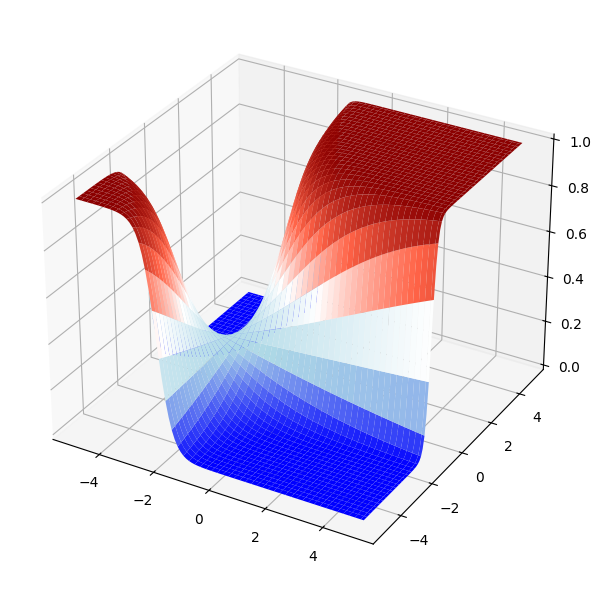

Plot 4: Cubic interaction: 1 + x1^3 + 0.5*x2^3 + 0.2*x1*x2


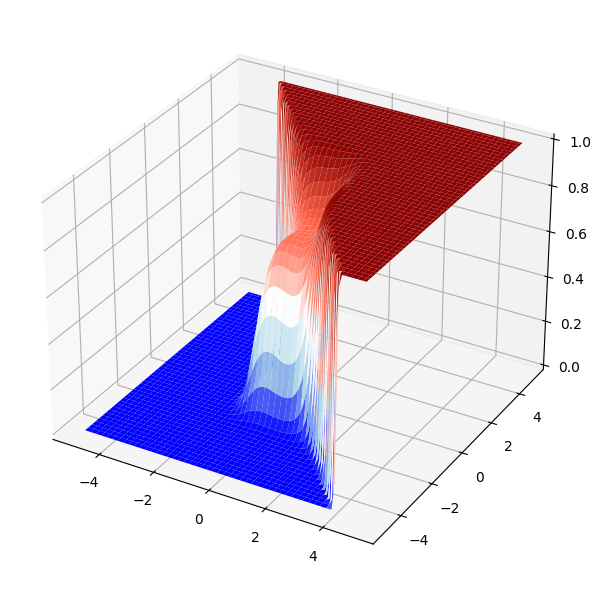

Plot 5: Mixed trigonometric and quadratic: 1 + 0.5*x1^2 - 0.3*cos(0.5*x2) + 0.4*x1*sin(0.5*x2)


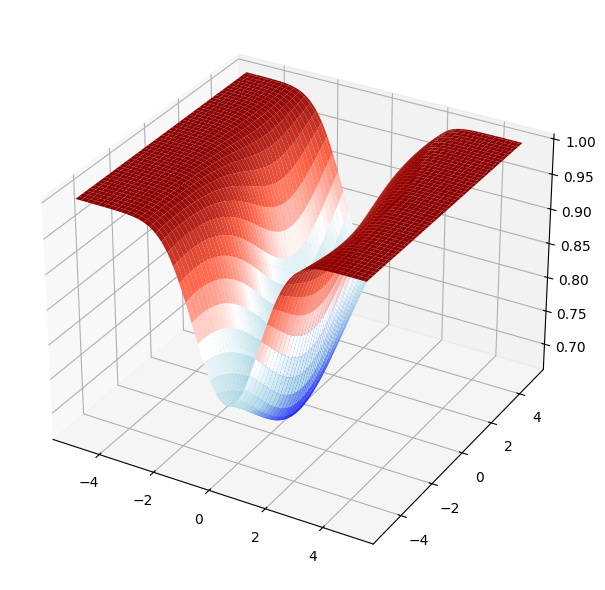

Plot 6: Sinusoidal influence: 1 + sin(x1) + 0.5*cos(x2) + 0.3*x1*x2


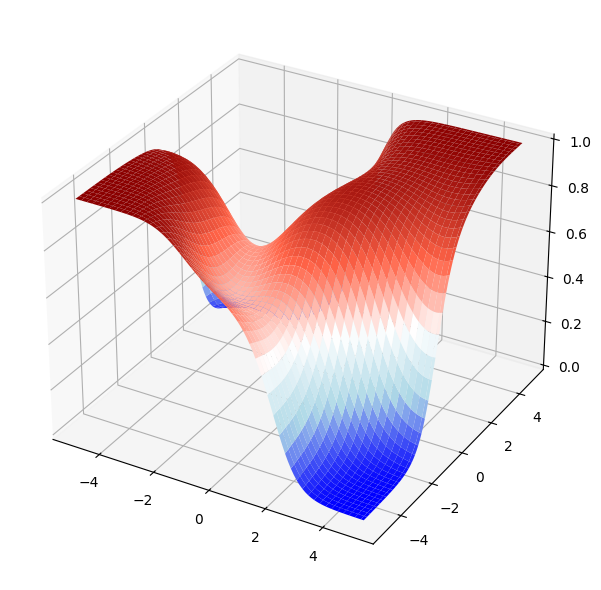

Plot 7: Exponential decay with quadratic terms: 1 + exp(-0.1*x1^2) + exp(-0.1*x2^2) + 0.2*x1*x2


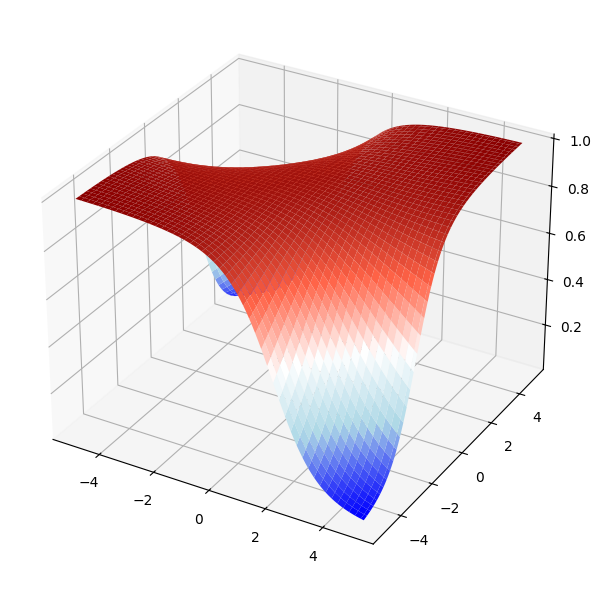

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from mpl_toolkits.mplot3d import Axes3D
from pathlib import Path

# Define the sigmoid function
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# Create a denser meshgrid for 3D plots
x1 = np.linspace(-5, 5, 100)
x2 = np.linspace(-5, 5, 100)
x1, x2 = np.meshgrid(x1, x2)

# Define logistic regression functions and their descriptions
functions = [
    {"formula": lambda x1, x2: 1 + x1 + x2, 
     "description": "Simple linear combination: 1 + x1 + x2"},
    {"formula": lambda x1, x2: 1 + 0.1 * x1**2 + 0.1 * x2**2, 
     "description": "Quadratic terms: 1 + 0.1*x1^2 + 0.1*x2^2"},
    {"formula": lambda x1, x2: 1 + x1 + 2 * x2 + x1 * x2, 
     "description": "Linear with interaction: 1 + x1 + 2*x2 + x1*x2"},
    {"formula": lambda x1, x2: 1 + x1**3 + 0.5 * x2**3 + 0.2 * x1 * x2, 
     "description": "Cubic interaction: 1 + x1^3 + 0.5*x2^3 + 0.2*x1*x2"},
    {"formula": lambda x1, x2: 1 + 0.5 * x1**2 - 0.3 * np.cos(0.5 * x2) + 0.4 * x1 * np.sin(0.5 * x2), 
     "description": "Mixed trigonometric and quadratic: 1 + 0.5*x1^2 - 0.3*cos(0.5*x2) + 0.4*x1*sin(0.5*x2)"},
    {"formula": lambda x1, x2: 1 + np.sin(x1) + 0.5 * np.cos(x2) + 0.3 * x1 * x2, 
     "description": "Sinusoidal influence: 1 + sin(x1) + 0.5*cos(x2) + 0.3*x1*x2"},
    {"formula": lambda x1, x2: 1 + np.exp(-0.1 * x1**2) + np.exp(-0.1 * x2**2) + 0.2 * x1 * x2, 
     "description": "Exponential decay with quadratic terms: 1 + exp(-0.1*x1^2) + exp(-0.1*x2^2) + 0.2*x1*x2"}
]

# Define a custom colormap using the specified palette
colors = ['#0000FF', '#ADD8E6', '#FFFFFF', '#FF6347', '#8B0000']  # Blue, Light Blue, White, Light Red, Dark Red
cmap = LinearSegmentedColormap.from_list("custom_blue_white_red", colors)

# Iterate through the defined functions and create plots
for idx, func in enumerate(functions, start=1):
    z = func["formula"](x1, x2)  # Compute the logistic function
    h = sigmoid(z)

    # Print the description
    print(f"Plot {idx}: {func['description']}")

    # Plot the function
    fig = plt.figure(figsize=(6, 6))
    ax = fig.add_subplot(111, projection='3d')
    ax.plot_surface(x1, x2, h, cmap=cmap, edgecolor='none')
    
    # Save the figure
    output_path = Path(OUTPUT_DIR) / f'logistic_regression_{idx}.png'
    plt.tight_layout()
    plt.savefig(output_path, bbox_inches='tight', pad_inches=0)
    plt.show()